# Water-limited regimes precede aerosol extreme events across the U.S. Southwest

This code reproduces Figures 1 and 2 from the paper

By: Juliana Mejia Sepulveda
email: julianamejia@arizona.edu

## 1. Libraries

In [26]:
# LIBRARIES
import pandas as pd
import xarray as xr
import numpy as np
from scipy import interpolate

import os
from multiprocessing import Pool

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from matplotlib import cm
from matplotlib import colors
from datetime import datetime
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import math
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import linregress, kendalltau
from scipy.stats import norm


import matplotlib.font_manager as fm

import seaborn as sns

In [2]:
# Directory with the .xlsx files
basedir = '/home/u32/julianamejia/data/aeronet_data/Sites_2.0Level/'

# Functio to read each .xlsx file
def read_aeronet_file(file):
    if file.endswith('.lev20.xlsx'):  # Check if it is an .xlsx file
        # Extract the station name from the file name
        station_name = os.path.splitext(file)[0]  # This removes the .xlsx extension
        
        # Complete file path
        file_path = os.path.join(basedir, file)
        
        # Read the .xlsx file
        df = pd.read_excel(file_path, usecols=['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'AOD_1020nm', 
                                               'AOD_870nm', 'AOD_675nm', 'AOD_500nm', 
                                               'AOD_440nm', 'AOD_380nm', 'AOD_340nm'], engine='openpyxl')
        
        # Return the station name and the DataFrame
        return station_name, df
    return None  # If the file does not match the condition, return None

# Function to process files in parallel
def process_files_in_parallel():
    # Get the list of files in the directory
    files = os.listdir(basedir)
    
    # Create a pool of processes
    with Pool() as pool:
        # Process the files in parallel
        results = pool.map(read_aeronet_file, files)
    
    # Filter out None results
    results = [result for result in results if result is not None]
    
    # Store the DataFrames: station name as the key
    dataframes = {station_name: df for station_name, df in results}
    
    return dataframes

# Execute parallel file processing
dataframes = process_files_in_parallel()

# Access the data by station name
for station, df in dataframes.items():
    print(f"Aeronet Data {station}:")

Aeronet Data aeronet_UCSB.lev20:
Aeronet Data aeronet_La_Jolla.lev20:
Aeronet Data aeronet_Sevilleta.lev20:
Aeronet Data aeronet_TABLE_MOUNTAIN_CA.lev20:
Aeronet Data aeronet_Los_Alamos.lev20:
Aeronet Data aeronet_Maricopa.lev20:
Aeronet Data aeronet_Rogers_Dry_Lake.lev20:
Aeronet Data aeronet_Railroad_Valley.lev20:
Aeronet Data aeronet_Tucson.lev20:
Aeronet Data aeronet_MISR-JPL.lev20:
Aeronet Data aeronet_Monterey.lev20:


In [3]:
# ============================================================
# AEE settings
# ============================================================
AOD_COL = "AOD_500nm"   # AOD wavelenght
MIN_EVENT_DAYS = 3      # AEE minimum duration

selected_sites = [
    "aeronet_Tucson.lev20",
    "aeronet_Maricopa.lev20",
    "aeronet_UCSB.lev20",
    "aeronet_La_Jolla.lev20",
    "aeronet_Sevilleta.lev20",
    "aeronet_TABLE_MOUNTAIN_CA.lev20",
    "aeronet_Railroad_Valley.lev20",
    "aeronet_Monterey.lev20",
]

In [4]:
# ============================================================
# Assigning the seasons
# ============================================================
def assign_season(month):
    """
    Assign meteorological season.
    DJF includes Dec-Jan-Feb.
    """
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    elif month in [9, 10, 11]:
        return "SON"

In [5]:
# ============================================================
# Preparing daily datasets
# ============================================================

def prepare_daily_site(df, aod_col=AOD_COL):
    """
    Takes one raw AERONET dataframe and returns daily mean AOD.

    Expected columns:
    - Date(dd:mm:yyyy)
    - Time(hh:mm:ss)
    - selected AOD column
    """

    df = df.copy()

    # Replace missing AERONET fill value
    df = df.replace(-999, np.nan)

    # Convert date column
    df["Date(dd:mm:yyyy)"] = pd.to_datetime(
        df["Date(dd:mm:yyyy)"],
        format="%d:%m:%Y",
        errors="coerce"
    )

    # Combine date and time into DateTime
    df["DateTime"] = pd.to_datetime(
        df["Date(dd:mm:yyyy)"].astype(str) + " " + df["Time(hh:mm:ss)"].astype(str),
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )

    # Drop invalid DateTime rows
    df = df.dropna(subset=["DateTime"])

    # Set DateTime index
    df = df.set_index("DateTime").sort_index()

    # Check AOD column
    if aod_col not in df.columns:
        raise ValueError(
            f"{aod_col} not found. Available AOD columns are: "
            f"{[c for c in df.columns if 'AOD' in c]}"
        )

    # Daily mean AOD
    daily = df[[aod_col]].resample("1D").mean()

    # Remove fully missing daily values
    daily = daily.dropna(subset=[aod_col])

    # Add time metadata
    daily["year"] = daily.index.year
    daily["month"] = daily.index.month
    daily["season"] = daily["month"].apply(assign_season)

    return daily

In [6]:
# ============================================================
# Applies AOD seasonal 90th percentile to each site
# ============================================================

def add_seasonal_extremes(daily, aod_col=AOD_COL):
    """
    Calculate seasonal 90th percentile AOD threshold for each site
    and identify daily values above the threshold.
    """

    daily = daily.copy()

    seasonal_thresholds = (daily.groupby("season")[aod_col].quantile(0.90).to_dict())

    daily["AOD90_seasonal"] = daily["season"].map(seasonal_thresholds)

    daily["extreme_day"] = daily[aod_col] > daily["AOD90_seasonal"]

    return daily, seasonal_thresholds

In [7]:
# ============================================================
# AEE identification
# ============================================================

def detect_aees(daily, aod_col=AOD_COL, min_days=MIN_EVENT_DAYS):
    """
    Detect Aerosol Extreme Events (AEEs) as episodes of at least three
    consecutive days above the seasonal AOD90 threshold for each site.
    """

    df = daily.copy()

    # Initialize columns
    df["AEE_day"] = False
    df["AEE_group"] = np.nan

    # Keep only extreme days
    extreme = df[df["extreme_day"]].copy()

    if extreme.empty:
        return pd.DataFrame(), df

    # Identify breaks in consecutive extreme days
    day_diff = extreme.index.to_series().diff().dt.days
    extreme["event_group"] = (day_diff != 1).cumsum()

    event_records = []

    for group_id, group in extreme.groupby("event_group"):

        duration = len(group)

        if duration >= min_days:

            start = group.index.min()
            end = group.index.max()

            event_records.append({
                "start_date": start,
                "end_date": end,
                "year": start.year,
                "month": start.month,
                "season": assign_season(start.month),
                "duration": duration,
                "AOD_mean": group[aod_col].mean(),
                "AOD_max": group[aod_col].max(),
                "AOD_sum": group[aod_col].sum(),
                "AOD_excess_mean": (group[aod_col] - group["AOD90_seasonal"]).mean(),
                "AOD_excess_max": (group[aod_col] - group["AOD90_seasonal"]).max(),})

            df.loc[group.index, "AEE_day"] = True
            df.loc[group.index, "AEE_group"] = group_id

    events = pd.DataFrame(event_records)

    if len(events) > 0:
        events = events.sort_values("start_date").reset_index(drop=True)

    return events, df

In [8]:
# ============================================================
# Apply for all selected Southwestern AERONET sites
# ============================================================

site_daily = {}
site_thresholds = {}
site_events = {}

for site in selected_sites:

    if site not in dataframes:
        print(f"Skipping {site}: not found in dataframes")
        continue

    print(f"Processing {site}")

    try:
        daily = prepare_daily_site(dataframes[site],aod_col=AOD_COL)

        daily, thresholds = add_seasonal_extremes(daily,aod_col=AOD_COL)

        events, daily_with_events = detect_aees(daily,aod_col=AOD_COL, min_days=MIN_EVENT_DAYS)

        site_daily[site] = daily_with_events
        site_thresholds[site] = thresholds
        site_events[site] = events

        print(f"  Daily records: {len(daily_with_events)}")
        print(f"  Extreme AOD days: {int(daily_with_events['extreme_day'].sum())}")
        print(f"  AEE days: {int(daily_with_events['AEE_day'].sum())}")
        print(f"  AEEs detected: {len(events)}")
        print()

    except Exception as e:
        print(f"  Error processing {site}: {e}")
        print()

Processing aeronet_Tucson.lev20
  Daily records: 4257
  Extreme AOD days: 427
  AEE days: 186
  AEEs detected: 38

Processing aeronet_Maricopa.lev20
  Daily records: 1983
  Extreme AOD days: 200
  AEE days: 73
  AEEs detected: 17

Processing aeronet_UCSB.lev20
  Daily records: 3603
  Extreme AOD days: 362
  AEE days: 133
  AEEs detected: 31

Processing aeronet_La_Jolla.lev20
  Daily records: 3230
  Extreme AOD days: 324
  AEE days: 102
  AEEs detected: 25

Processing aeronet_Sevilleta.lev20
  Daily records: 6625
  Extreme AOD days: 664
  AEE days: 266
  AEEs detected: 58

Processing aeronet_TABLE_MOUNTAIN_CA.lev20
  Daily records: 4212
  Extreme AOD days: 423
  AEE days: 184
  AEEs detected: 38

Processing aeronet_Railroad_Valley.lev20
  Daily records: 6021
  Extreme AOD days: 603
  AEE days: 258
  AEEs detected: 58

Processing aeronet_Monterey.lev20
  Daily records: 4129
  Extreme AOD days: 414
  AEE days: 197
  AEEs detected: 36



In [9]:
site_thresholds

{'aeronet_Tucson.lev20': {'DJF': 0.06649364285714286,
  'JJA': 0.17972403333333337,
  'MAM': 0.1080514375,
  'SON': 0.11493569487468319},
 'aeronet_Maricopa.lev20': {'DJF': 0.09923768811188811,
  'JJA': 0.19509915862068963,
  'MAM': 0.15059397871794872,
  'SON': 0.12086773333333332},
 'aeronet_UCSB.lev20': {'DJF': 0.10640907701193694,
  'JJA': 0.20921427692307693,
  'MAM': 0.1875831320261438,
  'SON': 0.19280750844277675},
 'aeronet_La_Jolla.lev20': {'DJF': 0.13225485908319184,
  'JJA': 0.22914414154447704,
  'MAM': 0.2089154444444445,
  'SON': 0.19415000000000004},
 'aeronet_Sevilleta.lev20': {'DJF': 0.058785647368421054,
  'JJA': 0.1817032753939394,
  'MAM': 0.11739423219696969,
  'SON': 0.10803703},
 'aeronet_TABLE_MOUNTAIN_CA.lev20': {'DJF': 0.04610030000000001,
  'JJA': 0.11726503901515152,
  'MAM': 0.08839992288135597,
  'SON': 0.07411},
 'aeronet_Railroad_Valley.lev20': {'DJF': 0.05172463076923077,
  'JJA': 0.184214796875,
  'MAM': 0.11961315538461541,
  'SON': 0.091711830306698

In [10]:
# ============================================================
# Build heatmap data: months x years
# ============================================================

month_order = np.arange(1, 13)

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def build_extreme_day_heatmap(daily):
    """
    Heatmap data with months as rows and years as columns.
    Values are number of days above seasonal AOD90.
    """

    heatmap = (daily.groupby(["month", "year"])["extreme_day"].sum().unstack("year"))

    heatmap = heatmap.reindex(index=month_order)
    heatmap.index = month_labels

    return heatmap

In [11]:
# ============================================================
# Build heatmaps for all selected sites
# ============================================================

site_heatmap_data = {}

for site, daily in site_daily.items():
    site_heatmap_data[site] = build_extreme_day_heatmap(daily)

site_heatmap_data.keys()

dict_keys(['aeronet_Tucson.lev20', 'aeronet_Maricopa.lev20', 'aeronet_UCSB.lev20', 'aeronet_La_Jolla.lev20', 'aeronet_Sevilleta.lev20', 'aeronet_TABLE_MOUNTAIN_CA.lev20', 'aeronet_Railroad_Valley.lev20', 'aeronet_Monterey.lev20'])

In [12]:
# ============================================================
# Tucson + Maricopa heatmap data
# ============================================================

tucson_site = "aeronet_Tucson.lev20"
maricopa_site = "aeronet_Maricopa.lev20"

tucson_heatmap_data = site_heatmap_data[tucson_site]
maricopa_heatmap_data = site_heatmap_data[maricopa_site]

# Align Tucson and Maricopa by year
t_union, m_union = tucson_heatmap_data.align(maricopa_heatmap_data, join="outer", axis=1)

# Combine using maximum number of extreme days per month-year cell
stacked = np.dstack([t_union.values, m_union.values])
combined_values = np.nanmax(stacked, axis=2)

combined_heatmap = pd.DataFrame(combined_values,index=t_union.index,columns=t_union.columns)

# Extend heatmap to show full period
full_years = np.arange(1999, 2025)
combined_heatmap = combined_heatmap.reindex(columns=full_years, fill_value=0)
combined_heatmap = combined_heatmap.fillna(0)

# Annotations
combined_annot = combined_heatmap.applymap( lambda x: f"{int(x)}" if x != 0 else "")

combined_heatmap

/tmp/ipykernel_1535033/3211778141.py:16: RuntimeWarning: All-NaN slice encountered
  combined_values = np.nanmax(stacked, axis=2)


year,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Jan,0.0,5.0,4.0,1.0,2.0,6.0,1.0,6.0,0.0,0,...,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
Feb,3.0,4.0,3.0,0.0,5.0,5.0,0.0,3.0,2.0,0,...,0.0,1.0,4.0,3.0,0.0,1.0,0.0,0.0,4.0,1.0
Mar,7.0,3.0,1.0,1.0,0.0,3.0,0.0,0.0,0.0,0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Apr,5.0,4.0,2.0,0.0,1.0,8.0,5.0,1.0,0.0,0,...,3.0,0.0,2.0,3.0,0.0,0.0,0.0,4.0,2.0,0.0
May,4.0,18.0,2.0,0.0,9.0,0.0,7.0,5.0,0.0,0,...,4.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,4.0,0.0
Jun,0.0,2.0,0.0,0.0,1.0,0.0,0.0,9.0,0.0,0,...,2.0,0.0,6.0,1.0,0.0,1.0,7.0,2.0,1.0,2.0
Jul,0.0,6.0,0.0,6.0,9.0,1.0,0.0,7.0,0.0,0,...,0.0,0.0,2.0,0.0,2.0,0.0,8.0,0.0,1.0,7.0
Aug,0.0,10.0,2.0,4.0,3.0,0.0,0.0,0.0,3.0,0,...,0.0,1.0,0.0,3.0,0.0,15.0,2.0,0.0,1.0,0.0
Sep,0.0,6.0,1.0,0.0,2.0,1.0,2.0,0.0,0.0,0,...,4.0,3.0,11.0,0.0,6.0,19.0,20.0,1.0,3.0,5.0
Oct,0.0,3.0,0.0,6.0,2.0,1.0,3.0,0.0,0.0,0,...,4.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,0.0,3.0


In [13]:
# ============================================================
# Tucson AEE dataframe for scatterplot
# ============================================================

tucson_grouped = site_events[tucson_site].copy()

tucson_grouped["start_date"] = pd.to_datetime(tucson_grouped["start_date"])
tucson_grouped = tucson_grouped.set_index("start_date").sort_index()

tucson_grouped.head()

,end_date,year,month,season,duration,AOD_mean,AOD_max,AOD_sum,AOD_excess_mean,AOD_excess_max
start_date,,,,,,,,,,
1999-03-28,1999-04-01,1999,3,MAM,5,0.188473,0.267240,0.942364,0.080421,0.159188
1999-04-28,1999-04-30,1999,4,MAM,3,0.148523,0.203018,0.445568,0.040471,0.094967
2000-01-17,2000-01-20,2000,1,DJF,4,0.078423,0.095055,0.313691,0.011929,0.028562
2000-02-24,2000-02-26,2000,2,DJF,3,0.084760,0.100864,0.254279,0.018266,0.034370
2000-05-16,2000-05-18,2000,5,MAM,3,0.118013,0.124198,0.354040,0.009962,0.016147


In [14]:
# ============================================================
# Highlight events
# ============================================================

highlight_events = {"Sep 2017": (2017, 9),"Sep 2020": (2020, 9), "Jun 2021": (2021, 6)}


def find_event_point_by_month(df, year, month):
    """
    Return (x, y) for the longest-duration AEE in a given year-month.
    Works with an event dataframe indexed by start_date.
    """

    if df is None or len(df) == 0:
        return None

    subset = df[(df.index.year == year) & (df.index.month == month)]

    if subset.empty:
        return None

    idx = subset["duration"].idxmax()

    return idx, subset.loc[idx, "AOD_mean"]

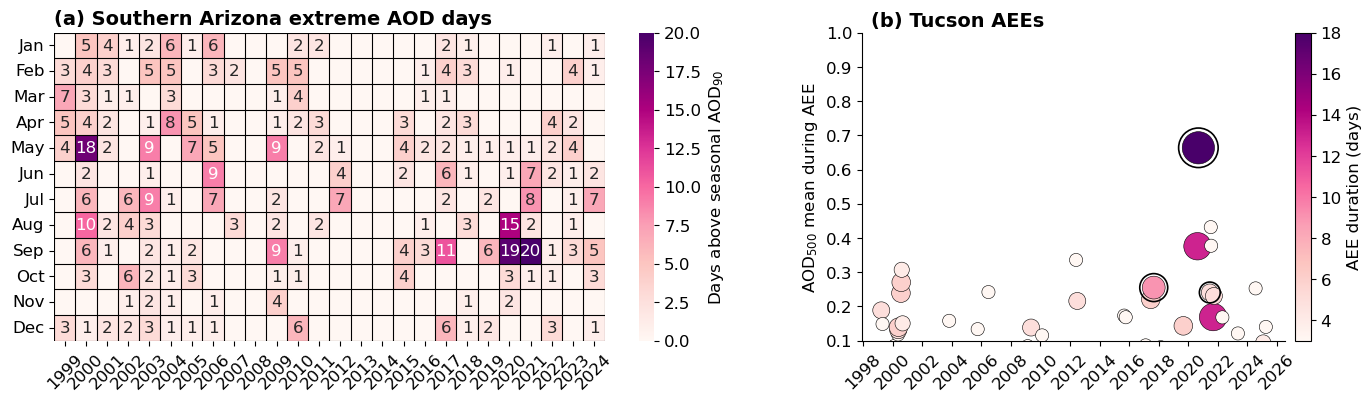

In [15]:
# ============================================================
# Figure 1: Southern Arizona extreme AOD days + Tucson AEEs
# ============================================================

plt.close("all")


vmin = combined_heatmap.min().min()
vmax = combined_heatmap.max().max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)


dur_min = tucson_grouped["duration"].min()
dur_max = tucson_grouped["duration"].max()
norm_dur = mpl.colors.Normalize(vmin=dur_min, vmax=dur_max)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 4), gridspec_kw={"width_ratios": [1.35, 1]})

# Panel (a): Tucson + Maricopa heatmap
sns.heatmap( combined_heatmap,  cmap="RdPu", annot=combined_annot, fmt="",  cbar=True,
    norm=norm,  ax=ax1, lw=0.5, linecolor="black",annot_kws={"size": 12})

ax1.set_title("(a) Southern Arizona extreme AOD days",fontsize=14, fontweight="bold", loc="left")

ax1.set_xlabel("")
ax1.set_ylabel("")

ax1.set_xticklabels( combined_heatmap.columns, rotation=45, fontsize=12,color="black")

ax1.set_yticks(np.arange(len(combined_heatmap.index)) + 0.5)
ax1.set_yticklabels(combined_heatmap.index,rotation=0,fontsize=12,color="black")

nrows, ncols = combined_heatmap.shape

ax1.hlines(np.arange(0, nrows + 1), *ax1.get_xlim(), colors="black", lw=0.8)

ax1.vlines(np.arange(0, ncols + 1),*ax1.get_ylim(), colors="black",lw=0.8)

# Heatmap colorbar
cbar1 = ax1.collections[0].colorbar
cbar1.set_label("Days above seasonal AOD$_{90}$", fontsize=12)
cbar1.ax.tick_params(labelsize=12)

# Panel (b): Tucson AEE scatter

sc = ax2.scatter( tucson_grouped.index,tucson_grouped["AOD_mean"], s=tucson_grouped["duration"] * 30,c=tucson_grouped["duration"],
    cmap="RdPu", edgecolor="black",linewidth=0.4, norm=norm_dur, zorder=3)

# Axes styling
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("black")
ax2.spines["bottom"].set_color("black")

ax2.tick_params( axis="both",which="both",colors="black",labelsize=12)

ax2.annotate( "(b) Tucson AEEs", xy=(0.02, 1.02), xycoords="axes fraction", fontsize=14,fontweight="bold", color="black")

ax2.set_ylim(0.1, 1)

ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.setp( ax2.get_xticklabels(),rotation=45, ha="center")

ax2.set_ylabel( "AOD$_{500}$ mean during AEE",fontsize=12,color="black")

ax2.set_xlabel("")


# Highlight AEEs
for label, (yr, mon) in highlight_events.items():

    result = find_event_point_by_month(tucson_grouped, yr, mon)

    if result is not None:

        x, y = result

        # Duration for marker size
        duration = tucson_grouped.loc[x, "duration"]

        # Highlight selected AEEs
        ax2.scatter( x, y,s=duration * 45,facecolor='none',edgecolor="black",linewidth=1.2, zorder=12 )


# Colorbar settings
cbar2 = fig.colorbar(sc, ax=ax2, pad=0.02)
cbar2.set_label("AEE duration (days)",fontsize=12, color="black")
cbar2.ax.tick_params(labelsize=12)

plt.savefig("Figure1_Southern_AZ_Tucson_AEEs.png", dpi=300, bbox_inches="tight")
plt.show()

### Figure 2

In [16]:
# ============================================================
# Sites for Figure 2
# ============================================================

figure2_sites = [
    site for site in selected_sites
    if site not in ["aeronet_Tucson.lev20", "aeronet_Maricopa.lev20"]
]

figure2_sites

['aeronet_UCSB.lev20',
 'aeronet_La_Jolla.lev20',
 'aeronet_Sevilleta.lev20',
 'aeronet_TABLE_MOUNTAIN_CA.lev20',
 'aeronet_Railroad_Valley.lev20',
 'aeronet_Monterey.lev20']

In [17]:
# ============================================================
# Duration across Figure 2 sites
# ============================================================

all_durations_fig2 = []

for site in figure2_sites:
    events = site_events.get(site, pd.DataFrame())

    if events is not None and len(events) > 0:
        all_durations_fig2.extend(events["duration"].values)

dur_min_fig2 = np.nanmin(all_durations_fig2)
dur_max_fig2 = np.nanmax(all_durations_fig2)

norm_dur_fig2 = mpl.colors.Normalize(vmin=dur_min_fig2,vmax=dur_max_fig2)

print("Figure 2 duration range:", dur_min_fig2, "to", dur_max_fig2)

Figure 2 duration range: 3 to 19


In [18]:
# ============================================================
# Clean site names for plotting
# ============================================================

def clean_site_name(site):
    return ( site.replace("aeronet_", "").replace(".lev20", "").replace("_", " "))

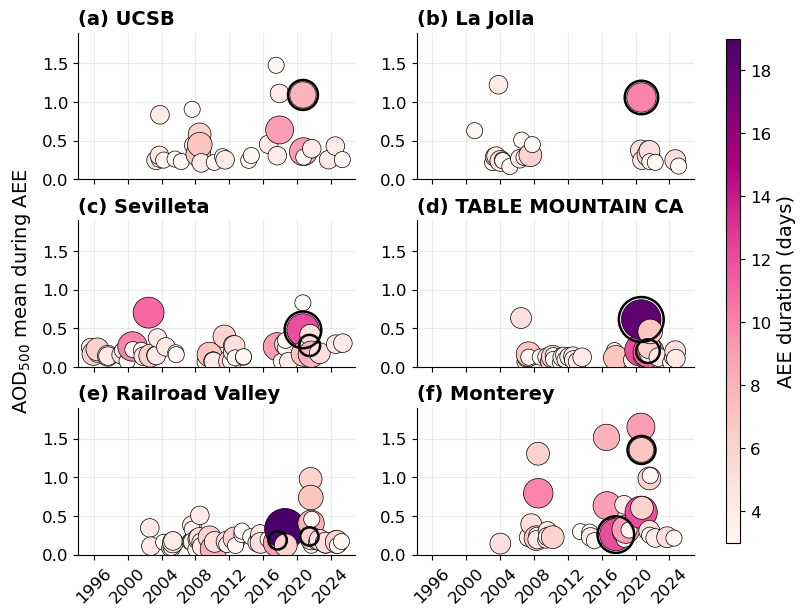

In [19]:
# ============================================================
# Figure 2: AEE scatterplots for additional Southwestern sites
# ============================================================

plt.close("all")

fig, axes = plt.subplots(3, 2, figsize=(8, 6), sharex=True, sharey=False)
axes = axes.ravel()

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

# y-axis setting
all_aod_means_fig2 = []

for site in figure2_sites:
    events = site_events.get(site, pd.DataFrame())

    if events is not None and len(events) > 0:
        all_aod_means_fig2.extend(events["AOD_mean"].values)

ymin = 0
ymax = np.nanmax(all_aod_means_fig2) * 1.15


# Plot each site
for i, (ax, site) in enumerate(zip(axes, figure2_sites)):

    events = site_events.get(site, pd.DataFrame())
    site_label = clean_site_name(site)

    if events is None or len(events) == 0:

        ax.text(0.5, 0.5, "No AEEs detected", transform=ax.transAxes,
                ha="center", va="center", fontsize=10)

    else:

        sc = ax.scatter(events["start_date"], events["AOD_mean"],
                        s=events["duration"] * 45, c=events["duration"],
                        cmap="RdPu", edgecolor="black", linewidth=0.5,
                        norm=norm_dur_fig2, zorder=3)

        # Highlight the main Tucson AEE months if captured by each site
        events_for_lookup = events.copy()
        events_for_lookup["start_date"] = pd.to_datetime(events_for_lookup["start_date"])
        events_for_lookup = events_for_lookup.set_index("start_date").sort_index()

        for label, (yr, mon) in highlight_events.items():

            result = find_event_point_by_month(events_for_lookup, yr, mon)

            if result is not None:

                x, y = result
                duration = events_for_lookup.loc[x, "duration"]

                #ax.annotate(label, xy=(x, y), xytext=(x, y + 0.5), fontsize=10,
                #            color="black", ha="center", zorder=5)

                ax.scatter(x, y, s=duration * 58, facecolor="none",
                           edgecolor="black", linewidth=1.8, zorder=4)

    # Panel title
    ax.set_title(f"{panel_labels[i]} {site_label}", fontsize=14,
                 fontweight="bold", loc="left")

    # Axes styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.tick_params(axis="both", which="both", colors="black", labelsize=12)
    ax.grid(alpha=0.25)
    ax.set_ylim(ymin, ymax)

    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(figure2_sites):]:
    ax.set_visible(False)


# Rotate x tick labels
plt.setp([label for ax in axes for label in ax.get_xticklabels()],
         rotation=45, ha="center")


# Shared y-axis label
fig.text(0.015, 0.52, "AOD$_{500}$ mean during AEE", va="center",
         rotation="vertical", fontsize=14, color="black")


# Shared colorbar
sm = mpl.cm.ScalarMappable(cmap="RdPu", norm=norm_dur_fig2)
sm.set_array([])

cbar_ax = fig.add_axes([0.91, 0.10, 0.018, 0.84])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="vertical")

cbar.set_label("AEE duration (days)", fontsize=14)
cbar.ax.tick_params(labelsize=12)


# Layout
plt.subplots_adjust(left=0.10, right=0.87, bottom=0.08, top=0.95,
                    wspace=0.22, hspace=0.28)

plt.savefig("Figure2_AERONET_SW_other_sites_AEE_scatterplots.png", dpi=300, bbox_inches="tight")

plt.show()

## Trend Analysis

In [20]:
# ============================================================
# Trend analysis
# ============================================================

supp_sites = [ site for site in selected_sites
    if site != "aeronet_Maricopa.lev20"]

supp_sites


['aeronet_Tucson.lev20',
 'aeronet_UCSB.lev20',
 'aeronet_La_Jolla.lev20',
 'aeronet_Sevilleta.lev20',
 'aeronet_TABLE_MOUNTAIN_CA.lev20',
 'aeronet_Railroad_Valley.lev20',
 'aeronet_Monterey.lev20']

In [21]:
# ============================================================
# Common year range across all supplementary sites
# ============================================================

all_start_years = []
all_end_years = []

for site in supp_sites:
    daily = site_daily.get(site, pd.DataFrame())
    if daily is not None and len(daily) > 0:
        all_start_years.append(daily.index.year.min())
        all_end_years.append(daily.index.year.max())

common_years = np.arange(min(all_start_years), max(all_end_years) + 1)

print("Common year range:", common_years.min(), "to", common_years.max())

Common year range: 1995 to 2025


In [22]:
# ============================================================
# Annual AEE frequency, intensity, and duration
# ============================================================

annual_aee_counts = {}
annual_aee_intensity = {}
annual_aee_duration = {}

INTENSITY_COLUMN = "AOD_max"

for site in supp_sites:

    daily = site_daily.get(site, pd.DataFrame())
    events = site_events.get(site, pd.DataFrame())

    if daily is None or len(daily) == 0:
        continue

    # Full year range available at each site
    full_years = np.arange(daily.index.year.min(), daily.index.year.max() + 1)

    if events is None or len(events) == 0:

        yearly_counts = pd.Series(0, index=full_years, name="n_AEEs", dtype=float)

        yearly_intensity = pd.Series(np.nan, index=full_years,name="mean_AEE_intensity", dtype=float)

        yearly_duration = pd.Series(np.nan, index=full_years, name="mean_AEE_duration", dtype=float)

    else:

        events = events.copy()

        if "year" not in events.columns:
            raise KeyError(f"'year' is missing from the event table for {site}.")

        if INTENSITY_COLUMN not in events.columns:
            raise KeyError(f"{INTENSITY_COLUMN!r} was not found for {site}.\n"
                           f"Available columns: {events.columns.tolist()}")

        if "duration" not in events.columns:
            raise KeyError(f"'duration' was not found for {site}.\n"
                           f"Available columns: {events.columns.tolist()}")

        # Annual AEE frequency
        yearly_counts = events.groupby("year").size()
        yearly_counts = yearly_counts.reindex(full_years, fill_value=0)
        yearly_counts = yearly_counts.astype(float).rename("n_AEEs")

        # Annual mean AEE intensity
        yearly_intensity = events.groupby("year")[INTENSITY_COLUMN].mean()
        yearly_intensity = yearly_intensity.reindex(full_years)
        yearly_intensity = yearly_intensity.astype(float).rename("mean_AEE_intensity")

        # Annual mean AEE duration
        yearly_duration = events.groupby("year")["duration"].mean()
        yearly_duration = yearly_duration.reindex(full_years)
        yearly_duration = yearly_duration.astype(float).rename("mean_AEE_duration")

    annual_aee_counts[site] = yearly_counts
    annual_aee_intensity[site] = yearly_intensity
    annual_aee_duration[site] = yearly_duration

In [23]:
for site in supp_sites:

    events = site_events.get(site, pd.DataFrame())

    if events is not None and len(events) > 0:

        print(site)
        print(events.columns.tolist())
        print(events.head())

        break

aeronet_Tucson.lev20
['start_date', 'end_date', 'year', 'month', 'season', 'duration', 'AOD_mean', 'AOD_max', 'AOD_sum', 'AOD_excess_mean', 'AOD_excess_max']
  start_date   end_date  year  month season  duration  AOD_mean   AOD_max  \
0 1999-03-28 1999-04-01  1999      3    MAM         5  0.188473  0.267240   
1 1999-04-28 1999-04-30  1999      4    MAM         3  0.148523  0.203018   
2 2000-01-17 2000-01-20  2000      1    DJF         4  0.078423  0.095055   
3 2000-02-24 2000-02-26  2000      2    DJF         3  0.084760  0.100864   
4 2000-05-16 2000-05-18  2000      5    MAM         3  0.118013  0.124198   

    AOD_sum  AOD_excess_mean  AOD_excess_max  
0  0.942364         0.080421        0.159188  
1  0.445568         0.040471        0.094967  
2  0.313691         0.011929        0.028562  
3  0.254279         0.018266        0.034370  
4  0.354040         0.009962        0.016147  


In [24]:
# ============================================================
# Mann-Kendall trend test + linear trend slope
# ============================================================

def mann_kendall_test(years, values, alpha=0.05):

    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)

    # Remove NaNs
    valid = np.isfinite(years) & np.isfinite(values)
    x = years[valid]
    y = values[valid]

    n = len(y)

    if n < 3:
        return {
            "n": n, "S": np.nan, "var_S": np.nan, "z": np.nan,
            "p": np.nan, "tau": np.nan,
            "slope": np.nan, "intercept": np.nan,
            "slope_p": np.nan, "slope_stderr": np.nan,
            "trend": "insufficient data"
        }

    # ========================================================
    # Mann-Kendall S statistic
    # ========================================================
    S = 0
    for k in range(n - 1):
        for j in range(k + 1, n):
            if y[j] > y[k]:
                S += 1
            elif y[j] < y[k]:
                S -= 1

    # Variance of S (tie correction)
    unique_y, counts = np.unique(y, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    var_S = (n * (n - 1) * (2 * n + 5) - tie_term) / 18.0

    # Standardized Z statistic -> Mann-Kendall p-value
    if var_S == 0:
        z = 0.0
        p = 1.0
    else:
        if S > 0:
            z = (S - 1) / np.sqrt(var_S)
        elif S < 0:
            z = (S + 1) / np.sqrt(var_S)
        else:
            z = 0.0
        p = 2 * (1 - stats.norm.cdf(abs(z)))

    tau = S / (0.5 * n * (n - 1))

    # Linear trend slope (ordinary least squares) and magnitude/direction of the trend
    slope, intercept, r_value, slope_p, slope_stderr = linregress(x, y)

    # Trend classification
    if p < alpha:
        if slope > 0:
            trend = "increasing"
        elif slope < 0:
            trend = "decreasing"
        else:
            trend = "no trend"
    else:
        trend = "no significant trend"

    return {
        "n": n,
        "S": S,
        "var_S": var_S,
        "z": z,
        "p": p,                # Mann-Kendall significance (use this for p<0.05 test)
        "tau": tau,
        "slope": slope,        # linear trend slope
        "intercept": intercept,
        "slope_p": slope_p,    # OLS regression p-value (reference only)
        "slope_stderr": slope_stderr,
        "trend": trend
    }

In [27]:
# ============================================================
# Mann-Kendall analysis:
# frequency + intensity + duration
# ============================================================

mk_frequency_results = {}
mk_intensity_results = {}
mk_duration_results = {}

for site in supp_sites:

    yearly_counts = annual_aee_counts.get(site)
    yearly_intensity = annual_aee_intensity.get(site)
    yearly_duration = annual_aee_duration.get(site)

    if yearly_counts is None:
        continue

    # Frequency
    frequency_years = (yearly_counts.index.values.astype(float))

    frequency_values = (yearly_counts.values.astype(float))

    mk_frequency_results[site] = mann_kendall_test(frequency_years,frequency_values)

    # Intensity
    if yearly_intensity is not None:

        intensity_years = (yearly_intensity.index.values.astype(float))

        intensity_values = (yearly_intensity.values.astype(float))

        mk_intensity_results[site] = mann_kendall_test(intensity_years,intensity_values)

    # Duration
    if yearly_duration is not None:

        duration_years = (yearly_duration.index.values.astype(float))

        duration_values = (yearly_duration.values.astype(float))

        mk_duration_results[site] = mann_kendall_test(duration_years,duration_values)

In [28]:
# ============================================================
# Mann-Kendall summary table
# ============================================================

mk_summary = []

for site in supp_sites:
    freq = mk_frequency_results.get(site)
    inten = mk_intensity_results.get(site)
    dur = mk_duration_results.get(site)

    if freq is None:
        continue

    mk_summary.append({
        "site": clean_site_name(site),

        "frequency_slope": freq["slope"],
        "frequency_p": freq["p"],
        "frequency_trend": freq["trend"],

        "intensity_slope": inten["slope"] if inten is not None else np.nan,
        "intensity_p": inten["p"] if inten is not None else np.nan,
        "intensity_trend": inten["trend"] if inten is not None else None,

        "duration_slope": dur["slope"] if dur is not None else np.nan,
        "duration_p": dur["p"] if dur is not None else np.nan,
        "duration_trend": dur["trend"] if dur is not None else None
    })

mk_summary_df = pd.DataFrame(mk_summary)
display(mk_summary_df.round(4))

,site,frequency_slope,frequency_p,frequency_trend,intensity_slope,intensity_p,intensity_trend,duration_slope,duration_p,duration_trend
0,Tucson,-0.0061,0.2288,no significant trend,0.0077,0.7619,no significant trend,0.0699,0.9349,no significant trend
1,UCSB,-0.0274,0.6568,no significant trend,0.0073,0.7526,no significant trend,0.0371,0.1741,no significant trend
2,La Jolla,-0.0099,0.8429,no significant trend,-0.0145,0.0868,no significant trend,0.0371,0.6313,no significant trend
3,Sevilleta,-0.0153,0.5533,no significant trend,0.0064,0.4596,no significant trend,0.0150,1.0000,no significant trend
4,TABLE MOUNTAIN CA,-0.0135,0.4851,no significant trend,-0.0021,0.7426,no significant trend,0.1237,0.4569,no significant trend
5,Railroad Valley,0.0285,0.6327,no significant trend,0.0060,0.9741,no significant trend,0.0381,0.8143,no significant trend
6,Monterey,0.0366,0.3508,no significant trend,0.0259,0.8368,no significant trend,-0.0028,0.6176,no significant trend


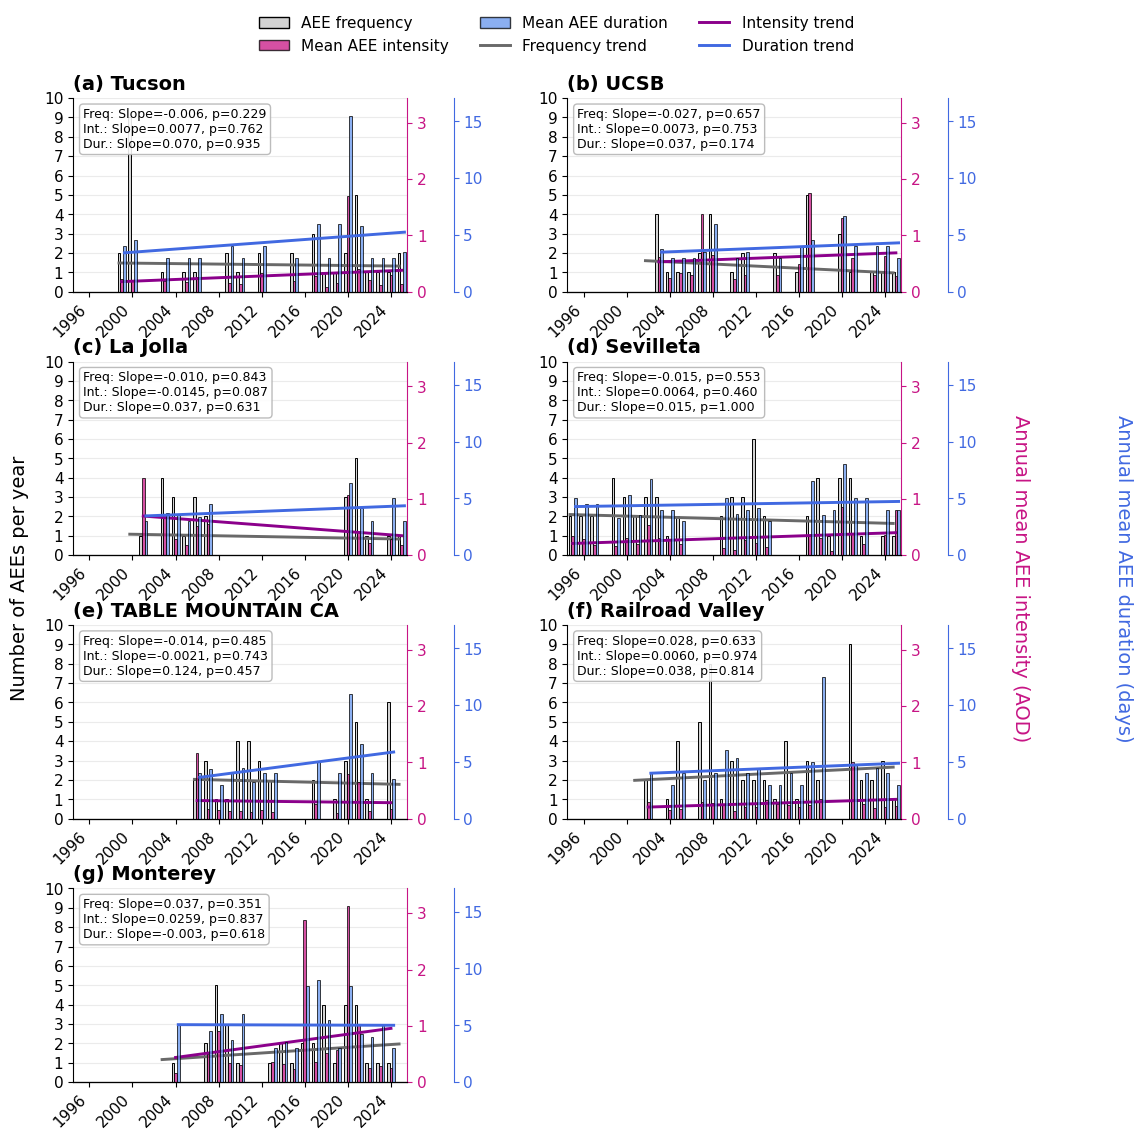

In [30]:
# ============================================================
# Supplementary Figure:
# Annual AEE frequency + intensity + duration
# Trends: Mann-Kendall test + linear trend slope
# ============================================================

plt.close("all")

n_sites = len(supp_sites)
ncols = 2
nrows = math.ceil(n_sites / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(11.5, 3 * nrows), sharex=True, sharey=False)
axes = np.atleast_1d(axes).ravel()

panel_labels = [f"({chr(97 + i)})" for i in range(len(axes))]

xmin = common_years.min() - 0.5
xmax = common_years.max() + 0.5

max_count_all = 0
max_intensity_all = 0
max_duration_all = 0

for site in supp_sites:

    yearly_counts = annual_aee_counts.get(site)
    yearly_intensity = annual_aee_intensity.get(site)
    yearly_duration = annual_aee_duration.get(site)

    if yearly_counts is not None and len(yearly_counts) > 0:
        max_count_all = max(max_count_all, np.nanmax(yearly_counts.values))

    if yearly_intensity is not None:
        finite_intensity = yearly_intensity.dropna()
        if len(finite_intensity) > 0:
            max_intensity_all = max(max_intensity_all, finite_intensity.max())

    if yearly_duration is not None:
        finite_duration = yearly_duration.dropna()
        if len(finite_duration) > 0:
            max_duration_all = max(max_duration_all, finite_duration.max())


left_ylim_top = max(max_count_all + 1, 2)

if max_intensity_all > 0:
    intensity_ylim_top = max_intensity_all * 1.10
else:
    intensity_ylim_top = 1

if max_duration_all > 0:
    duration_ylim_top = max_duration_all * 1.10
else:
    duration_ylim_top = 5

bar_width = 0.25


for i, (ax, site) in enumerate(zip(axes, supp_sites)):

    yearly_counts = annual_aee_counts.get(site)
    yearly_intensity = annual_aee_intensity.get(site)
    yearly_duration = annual_aee_duration.get(site)

    if yearly_counts is None or yearly_intensity is None or yearly_duration is None:
        ax.set_visible(False)
        continue

    site_years = yearly_counts.index.values.astype(float)
    counts = yearly_counts.values.astype(float)
    intensity = yearly_intensity.values.astype(float)
    duration = yearly_duration.values.astype(float)

    ax2 = ax.twinx()
    ax3 = ax.twinx()
    ax3.spines["right"].set_position(("axes", 1.14))

    site_label = clean_site_name(site)

    # Frequency, intensity and duration bars
    ax.bar(site_years - bar_width, counts, width=bar_width, color="lightgray",
           edgecolor="black", linewidth=0.7, zorder=3)

    ax2.bar(site_years, intensity, width=bar_width, color="mediumvioletred",
            edgecolor="black", linewidth=0.7, alpha=0.75, zorder=2)

    ax3.bar(site_years + bar_width, duration, width=bar_width, color="cornflowerblue",
            edgecolor="black", linewidth=0.7, alpha=0.75, zorder=1)


    # Frequency trend
    mk_freq = mann_kendall_test(site_years, counts)

    if np.isfinite(mk_freq["slope"]):
        freq_trend = mk_freq["intercept"] + mk_freq["slope"] * site_years
        ax.plot(site_years - bar_width, freq_trend, color="dimgray", linewidth=2.1, zorder=6)
        freq_stats = f"Freq: Slope={mk_freq['slope']:.3f}, p={mk_freq['p']:.3f}"
    else:
        freq_stats = "Freq: insufficient data"


    # Intensity trend
    intensity_valid = np.isfinite(site_years) & np.isfinite(intensity)
    intensity_years = site_years[intensity_valid]
    intensity_values = intensity[intensity_valid]

    mk_intensity = mann_kendall_test(intensity_years, intensity_values)

    if np.isfinite(mk_intensity["slope"]):
        intensity_trend = mk_intensity["intercept"] + mk_intensity["slope"] * intensity_years
        ax2.plot(intensity_years, intensity_trend, color="darkmagenta", linewidth=2.1, zorder=7)
        intensity_stats = f"Int.: Slope={mk_intensity['slope']:.4f}, p={mk_intensity['p']:.3f}"
    else:
        intensity_stats = "Int.: insufficient data"


    # Duration trend
    duration_valid = np.isfinite(site_years) & np.isfinite(duration)
    duration_years = site_years[duration_valid]
    duration_values = duration[duration_valid]

    mk_duration = mann_kendall_test(duration_years, duration_values)

    if np.isfinite(mk_duration["slope"]):
        duration_trend = mk_duration["intercept"] + mk_duration["slope"] * duration_years
        ax3.plot(duration_years + bar_width, duration_trend, color="royalblue", linewidth=2.1, zorder=8)
        duration_stats = f"Dur.: Slope={mk_duration['slope']:.3f}, p={mk_duration['p']:.3f}"
    else:
        duration_stats = "Dur.: insufficient data"


    ax.set_title(f"{panel_labels[i]} {site_label}", fontsize=14, fontweight="bold", loc="left")

    stats_text = f"{freq_stats}\n{intensity_stats}\n{duration_stats}"

    ax.text(0.03, 0.95, stats_text, transform=ax.transAxes, va="top", ha="left",
            fontsize=9, bbox=dict(boxstyle="round", facecolor="white",alpha=0.88, edgecolor="0.7"), zorder=20)


    # Frequency axis
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.tick_params(axis="both", labelsize=11, colors="black")
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(axis="y", alpha=0.25, zorder=0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, left_ylim_top)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))


    # Intensity axis
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_color("mediumvioletred")
    ax2.tick_params(axis="y", labelsize=11, colors="mediumvioletred")
    ax2.set_ylim(0, intensity_ylim_top)


    # Duration axis
    ax3.spines["top"].set_visible(False)
    ax3.spines["left"].set_visible(False)
    ax3.spines["right"].set_color("royalblue")
    ax3.tick_params(axis="y", labelsize=11, colors="royalblue", pad=3)
    ax3.set_ylim(0, duration_ylim_top)

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax2.set_ylabel("")
    ax3.set_ylabel("")


for ax in axes[len(supp_sites):]:
    ax.set_visible(False)

for ax in axes[:len(supp_sites)]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")


fig.text(0.025, 0.5, "Number of AEEs per year", va="center", rotation="vertical", fontsize=14, color="black")

fig.text(0.895, 0.5, "Annual mean AEE intensity (AOD)", va="center",rotation=270, fontsize=14, color="mediumvioletred")

fig.text(0.985, 0.5, "Annual mean AEE duration (days)", va="center", rotation=270, fontsize=14, color="royalblue")


legend_elements = [
    Patch(facecolor="lightgray", edgecolor="black", label="AEE frequency"),
    Patch(facecolor="mediumvioletred", edgecolor="black", alpha=0.75, label="Mean AEE intensity"),
    Patch(facecolor="cornflowerblue", edgecolor="black", alpha=0.75, label="Mean AEE duration"),
    Line2D([0], [0], color="dimgray", lw=2.1, label="Frequency trend"),
    Line2D([0], [0], color="darkmagenta", lw=2.1, label="Intensity trend"),
    Line2D([0], [0], color="royalblue", lw=2.1, label="Duration trend")]

fig.legend(handles=legend_elements, loc="upper center", ncol=3, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 0.98))

plt.subplots_adjust(left=0.08, right=0.80, bottom=0.08, top=0.90, wspace=0.48, hspace=0.36)

plt.savefig("ExtendedDataFig1_FreqDurInt_Trends.png",dpi=300, bbox_inches="tight")

plt.show()